# (01) poisson + BALLS64: (32, 128.0)

project = ```iP-VAE```, host = ```yoru```, device = ```cuda:0```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## Trainer

In [3]:
model_type = 'poisson'
npix = 64
cfg_vae, cfg_tr = default_configs(model_type, f'BALLS{npix}')

cfg_vae['n_latents'] = int(npix * 1.2)

cfg_vae['seq_len'] = 32
cfg_tr['kl_beta'] = 128.0

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  315.5 K   |
|     ———     |    ———     |
|    layer    |  315.5 K   |
+-------------+------------+

poisson_BALLS64_t-32_z-[76]_u-10,du-10_<grad|lin>
b400-ep1000-lr(0.0005)_beta(128:0.1)_temp(0.01:0.5)_gr(5000)_(2025_03_04,12:16)

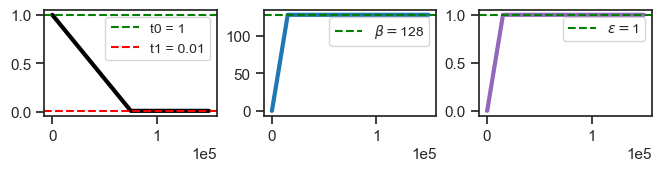

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [5]:
tr.n_iters

150000

In [6]:
print(tr.model.layer)
print(tr.model.layer.n_exp)

PoissonLayer(input_dim=4096, latent_dim=76, temperature=1, beta_inner=1, eps=1)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:0', dtype=torch.int32)

In [7]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([1.], device='cuda:0', grad_fn=<ExpBackward0>),)

In [8]:
# cm = ''
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 1000, avg loss: -479.358: 100%|███| 1000/1000 [7:53:37<00:00, 28.42s/it]


In [9]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0050], device='cuda:0', grad_fn=<ExpBackward0>),)

In [10]:
print(tr.model.layer.n_exp)

tensor([188, 227, 257, 287, 315, 343, 365, 385, 400, 412, 420, 425, 429, 429,
        433, 434, 436, 437, 436, 437, 439, 439, 439, 440, 441, 442, 442, 442,
        442, 444, 445, 445], device='cuda:0', dtype=torch.int32)

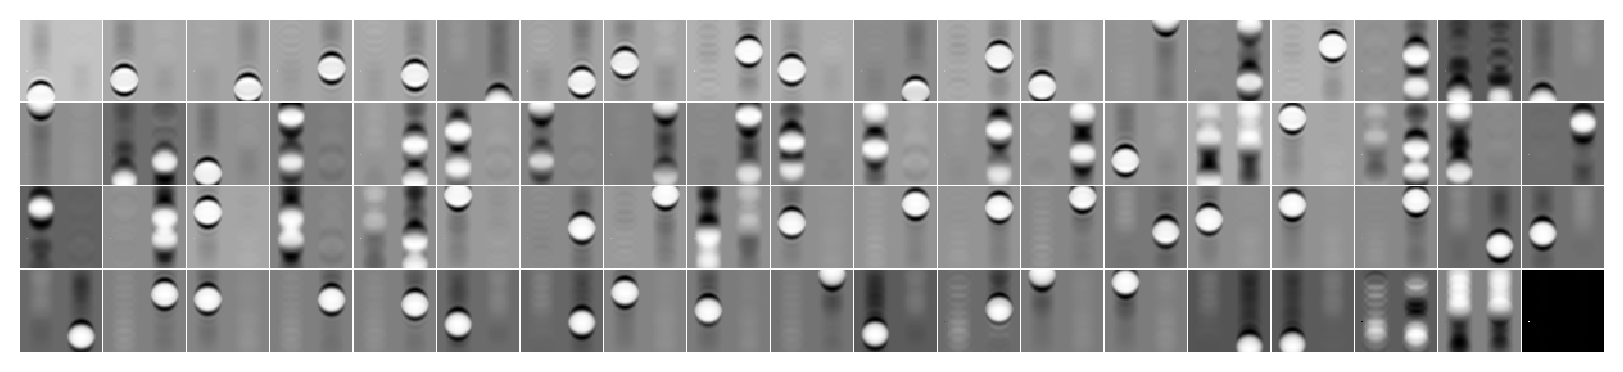

In [11]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0), nrows=4);

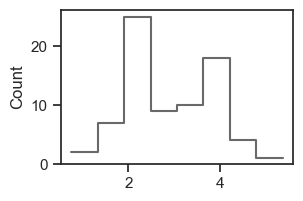

In [12]:
histplot(u0, color='dimgrey')
plt.show()

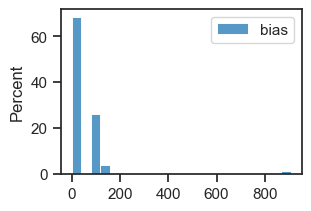

In [13]:
fig, ax = create_figure()

sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

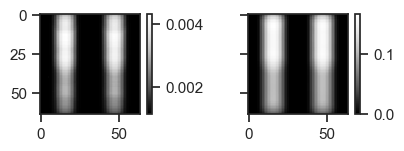

In [14]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(npix, npix)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

100%|███████████████████████████████████| 2/2 [00:04<00:00,  2.09s/it]


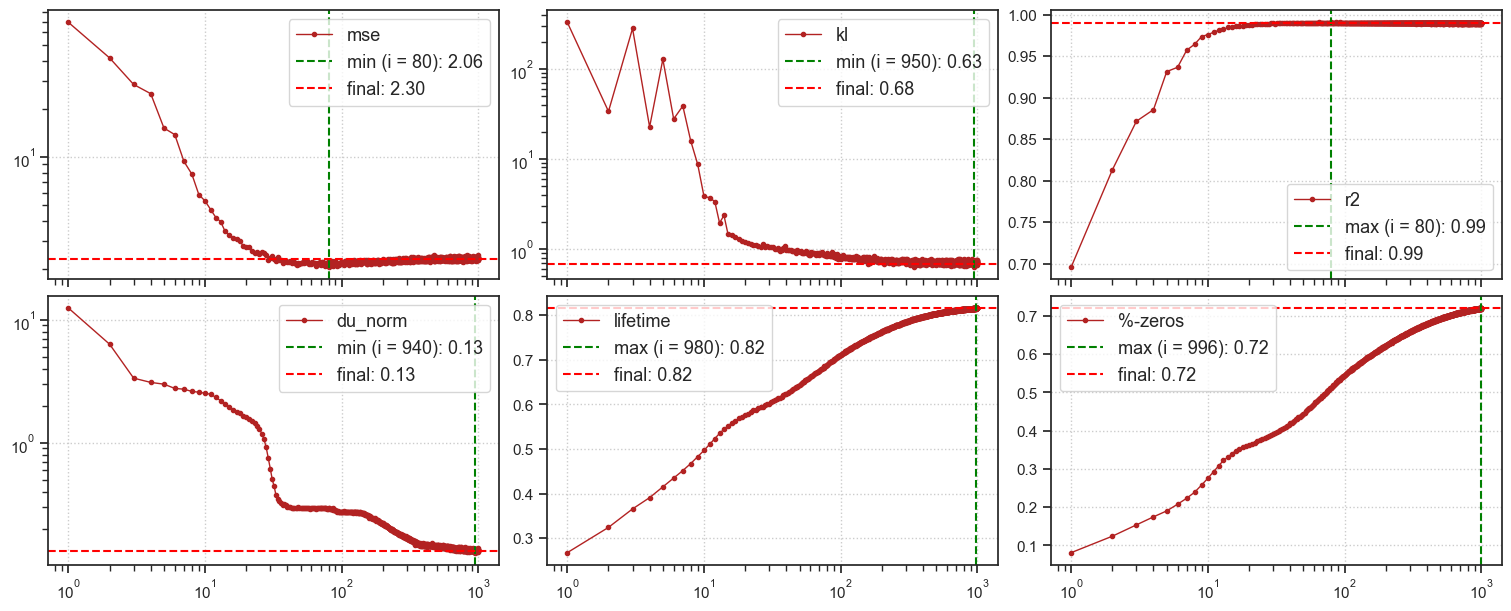

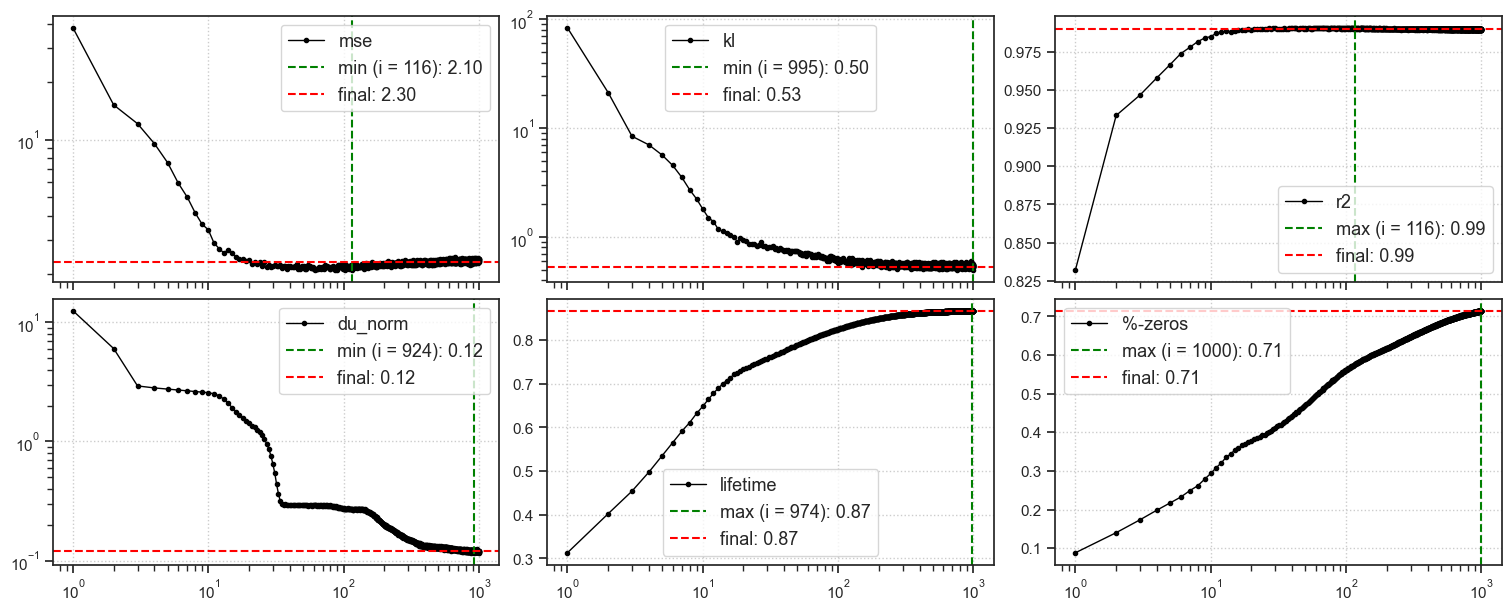

CPU times: user 11.2 s, sys: 230 ms, total: 11.4 s
Wall time: 11.4 s


In [15]:
%%time

kws = dict(
    seq_total=1000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = {
    k: tr.analysis(k, **kws)
    for k in ['vld', 'tst']
}
_ = plot_convergence(results['tst'], color='firebrick')
_ = plot_convergence(results['vld'], color='k')

In [20]:
from analysis.linreg import untangle_score

output = untangle_score(tr, seq_total=1000, seq_batch_sz=100)

100%|███████████████████████████████| 125/125 [04:15<00:00,  2.04s/it]


In [21]:
print(f"r2 tst:", output['r2_zg']['tst'])

r2 tst:
{
    1: array([-1.6319821 ,  0.72672826], dtype=float32),
    100: array([0.9737534, 0.9901319], dtype=float32),
    200: array([0.98411494, 0.9894894 ], dtype=float32),
    300: array([0.98571974, 0.98771966], dtype=float32),
    400: array([0.98594934, 0.9876326 ], dtype=float32),
    500: array([0.98411584, 0.9878618 ], dtype=float32),
    600: array([0.9840913 , 0.98761535], dtype=float32),
    700: array([0.98281133, 0.9870516 ], dtype=float32),
    800: array([0.98209316, 0.9878183 ], dtype=float32),
    900: array([0.9832502, 0.9880444], dtype=float32),
    1000: array([0.984105 , 0.9883092], dtype=float32)
}

100%|█████████████████████████████████| 10/10 [03:30<00:00, 21.00s/it]


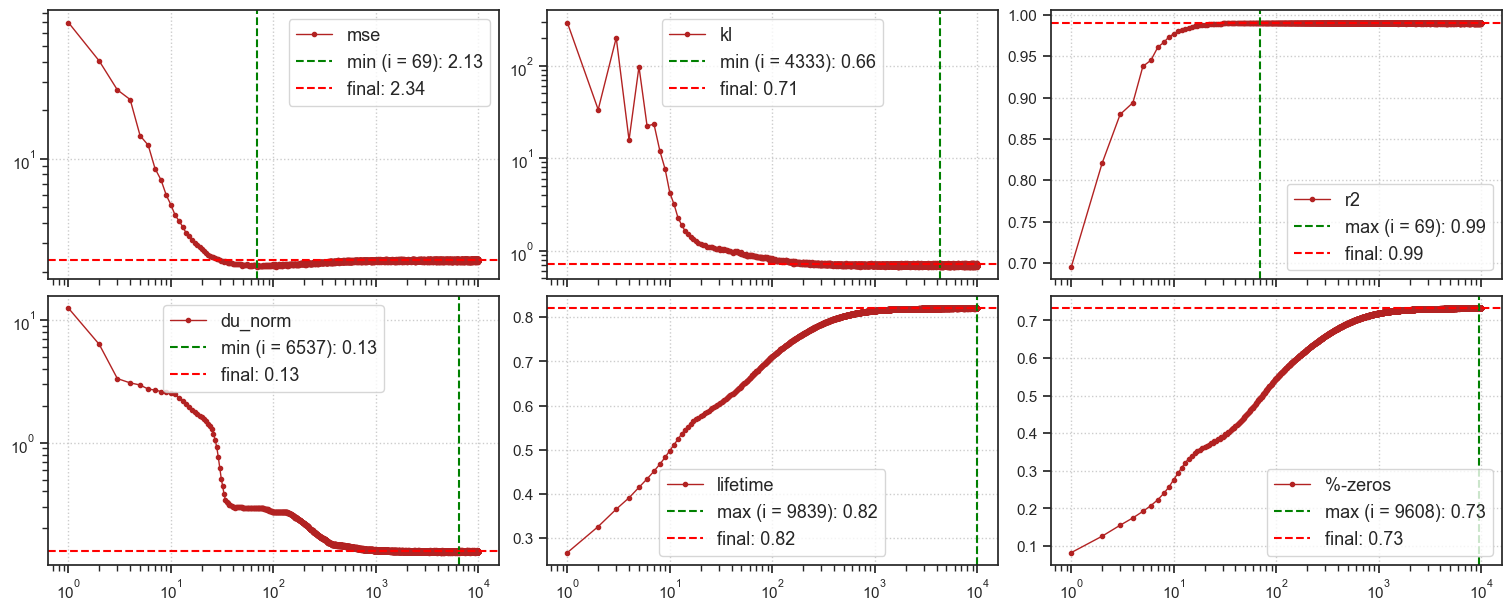

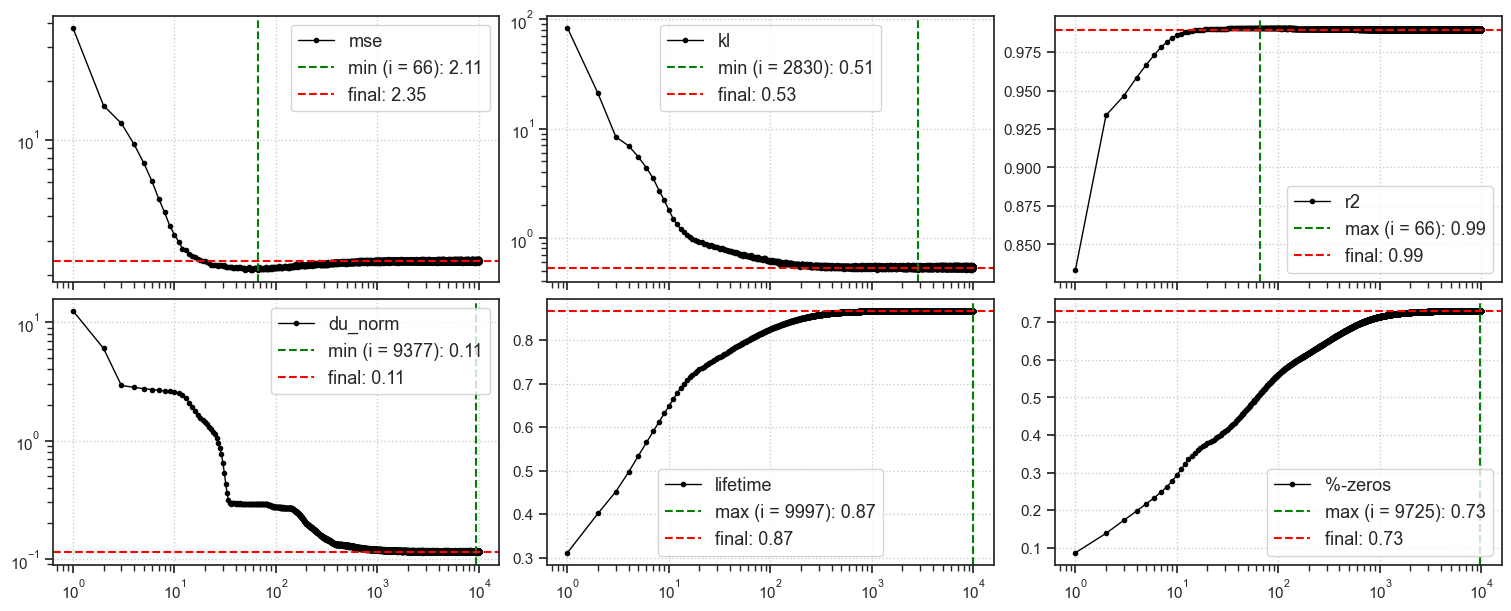

CPU times: user 7min 36s, sys: 5.36 s, total: 7min 42s
Wall time: 7min 36s


In [22]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=100,
    n_data_batches=10,
)
convergence_results = {
    k: tr.analysis(k, **kws)
    for k in ['vld', 'tst']
}
_ = plot_convergence(convergence_results['tst'], color='firebrick')
_ = plot_convergence(convergence_results['vld'], color='k')